This notebook will be used to perform anomaly detection on credit card transaction data using the isolation forest algorithm.

In [23]:
# Importing libraries

#!pip install pandas numpy seaborn matplotlib scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import random
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('All libraries imported successfully!')

All libraries imported successfully!


In [24]:
# Dataset loading and preprocessing

url = 'https://media.geeksforgeeks.org/wp-content/uploads/20240402160319/creditcard.csv'
credit_data = pd.read_csv(url, nrows=40000)  # Load a sample of 40,000 rows for faster processing
credit_data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [25]:
# Standardizing the features (excluding the 'Class' column as it is the target variable)

scaler = StandardScaler().fit_transform(credit_data.loc[:,credit_data.columns != 'Class'])
scaled_data = scaler[0:40000]
df = pd.DataFrame(data=scaled_data)
X = credit_data.drop(columns=['Class'])
y = credit_data['Class']


In [26]:
# Fitting the model 

outlier_fraction = len(credit_data[credit_data['Class']==1]) / float(len(credit_data[credit_data['Class']==0])) # Fraction of outliers in the dataset
model = IsolationForest(n_estimators = 100, contamination = outlier_fraction, random_state=RANDOM_SEED)
model.fit(df)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.0026067776218167233
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [27]:
# Evaluating the model 

scores_prediction = model.decision_function(df)
y_pred = model.predict(df)
# convert predictions to 0 for normal and 1 for anomaly
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1
acc = accuracy_score(y, y_pred)
print(f'Accuracy in finding anomaly: {acc:.5f}')

Accuracy in finding anomaly: 0.99718


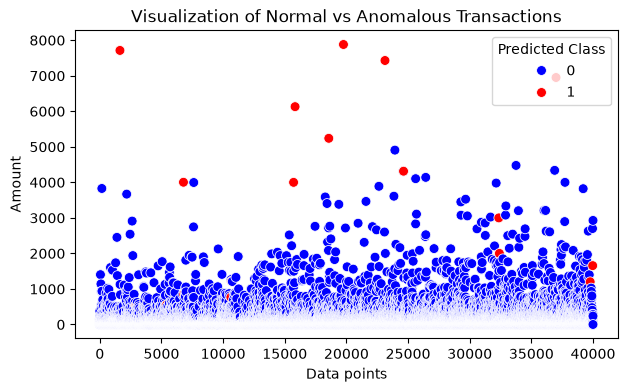

In [28]:
# Visualization

y_feature = credit_data['Amount']
credit_data['predicted_class'] = y_pred

plt.figure(figsize=(7,4))
sns.scatterplot(
    x = credit_data.index,
    y = y_feature,
    hue = credit_data['predicted_class'],
    palette = {0: 'blue',  # Normal transactions
               1: 'red'},  # Anomalous transactions
    s = 50, 
)
plt.title('Visualization of Normal vs Anomalous Transactions')
plt.xlabel('Data points')
plt.ylabel(y_feature.name)
plt.legend(title='Predicted Class', loc='best')
plt.show()


As we can see in the above plot, the isolation forest model is able to identify anomalous instances with little overlap.

#### Advantages of Isolation Forest:
1. Works well w high dimensional datasets
2. Works even on irregular data
3. Robust to outliers 
4. Easy to implement and to interpret
5. Low computational overhead makes it ideal for real-time anomaly detection

#### Drawbacks:
1. May overfit small or imbalanced datasets
2. Struggles to detect global anomalies, spanning multiple regions
3. Sensitive to correlated features, which may cause unnecessary splits and reduce accuracy
4. Not ideal for sequential time-series or dependent data
5. High noise may cause false positives. 